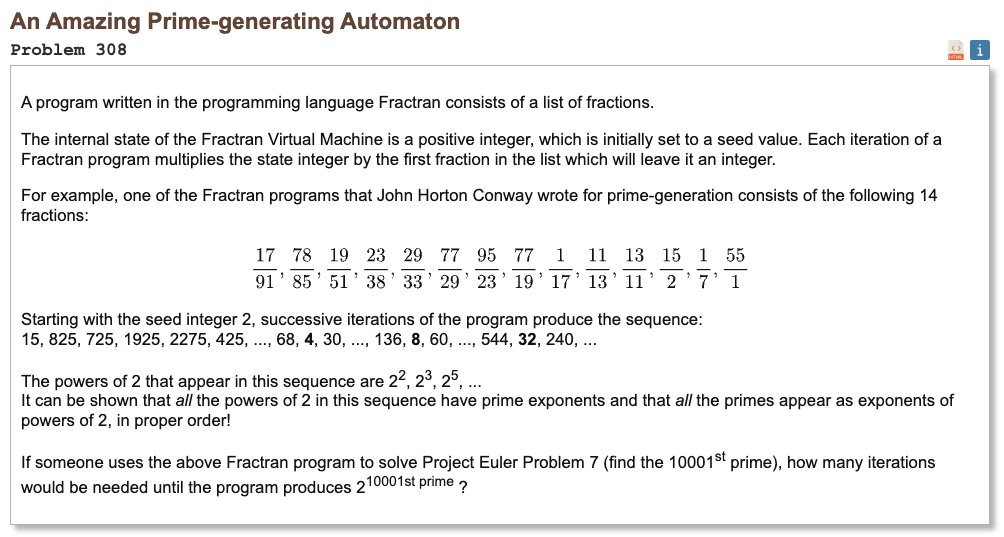

## Initial approach

* simulate the Fractran machine by storing prime exponents instead of huge integers
* each fraction only changes a few prime exponents
* jump repeated identical transitions instead of applying them one by one
* detect powers of 2 by checking that all other prime exponents are zero
* count those power-of-2 hits until the 10001st one
* the exponent at that point is the 10001st prime
* the required answer is the number of Fractran iterations needed to reach it

In [1]:
def factor_vector(n, primes):
    out = [0] * len(primes)

    for i, p in enumerate(primes):
        while n % p == 0:
            out[i] += 1
            n //= p

    return out

def can_apply(state, need):
    return all(state[i] >= need[i] for i in range(len(state)))

def jump_count(state, idx, needs, deltas):
    need = needs[idx]
    delta = deltas[idx]

    jump = 10 ** 30

    for i in range(len(state)):
        if need[i] > 0 and delta[i] < 0:
            jump = min(jump, state[i] // need[i])

    if jump == 10 ** 30:
        jump = 1

    stop = jump + 1

    for j in range(idx):
        other_need = needs[j]
        first_possible = 0
        possible = True

        for i in range(len(state)):
            if state[i] >= other_need[i]:
                continue

            if delta[i] <= 0:
                possible = False
                break

            first_possible = max(
                first_possible,
                (other_need[i] - state[i] + delta[i] - 1) // delta[i]
            )

        if possible and first_possible >= 1:
            stop = min(stop, first_possible)

    return max(1, min(jump, stop - 1))

def solve(target):
    primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29]

    fractions = [
        (17, 91),
        (78, 85),
        (19, 51),
        (23, 38),
        (29, 33),
        (77, 29),
        (95, 23),
        (77, 19),
        (1, 17),
        (11, 13),
        (13, 11),
        (15, 14),
        (15, 2),
        (55, 1)
    ]

    needs = [factor_vector(den, primes) for num, den in fractions]

    deltas = []
    for num, den in fractions:
        num_vec = factor_vector(num, primes)
        den_vec = factor_vector(den, primes)
        deltas.append([num_vec[i] - den_vec[i] for i in range(len(primes))])

    state = [1] + [0] * (len(primes) - 1)
    iterations = 0
    found = 0

    while True:
        for idx in range(len(fractions)):
            if can_apply(state, needs[idx]):
                step = jump_count(state, idx, needs, deltas)

                for i in range(len(state)):
                    state[i] += deltas[idx][i] * step

                iterations += step

                if all(state[i] == 0 for i in range(1, len(state))):
                    found += 1

                    if found == target:
                        return iterations

                break

```python
%%time
result = solve(10001)
print("Result:", result)
```

* needs optimization (code took longer than 10 minutes to run)